In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Qiskit components
import qiskit
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_algorithms.utils import algorithm_globals

try:
    # This is for Qiskit 1.x+
    from qiskit.primitives import StatevectorSampler as Sampler
except ImportError:
    try:
        # This is for older Qiskit versions
        from qiskit.primitives import Sampler
    except ImportError:
        # Final fallback for certain 1.x configurations
        from qiskit_aer.primitives import Sampler

# Ensure consistent results
algorithm_globals.random_seed = 10598
print(f"Ready with Qiskit version: {qiskit.__version__}")

Ready with Qiskit version: 2.3.0


In [3]:
def prepare_data(n_features=4):
    cancer = datasets.load_breast_cancer()
    # 70/30 split
    X_train, X_test, y_train, y_test = train_test_split(
        cancer.data, cancer.target, test_size=0.2, random_state=109
    )
    
    # Standardize and Reduce to 4 dimensions
    scaler = StandardScaler().fit(X_train)
    X_train = PCA(n_components=n_features).fit_transform(scaler.transform(X_train))
    X_test = PCA(n_components=n_features).fit_transform(scaler.transform(X_test))
    
    # Scale to [-1, 1] for the quantum feature map
    minmax = MinMaxScaler(feature_range=(-1, 1)).fit(X_train)
    X_train = minmax.transform(X_train)
    X_test = minmax.transform(X_test)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_data(n_features=4)
# We use a subset for faster training in this demo
X_train_sub, y_train_sub = X_train[:40], y_train[:40]
X_test_sub, y_test_sub = X_test[:10], y_test[:10]
print("Data prepared for 4-qubit Quantum SVM.")

Data prepared for 4-qubit Quantum SVM.


In [4]:
n_qubits = 4
# 1. Feature Map (zz_feature_map function to avoid warning)
f_map = zz_feature_map(n_qubits, reps=2, entanglement='linear')

# 2. Kernel Setup
kernel = FidelityQuantumKernel(fidelity=ComputeUncompute(Sampler()), feature_map=f_map)

# 3. Model & Training
qsvc = QSVC(quantum_kernel=kernel)
print("Training QSVM...")
qsvc.fit(X_train_sub, y_train_sub)

# 4. Results
accuracy = qsvc.score(X_test_sub, y_test_sub)
preds = qsvc.predict(X_test_sub)

print("\n--- Final Results ---")
print(f"Ground Truth: {y_test_sub}")
print(f"Predictions:  {preds}")
print(f"Accuracy:     {accuracy * 100:.2f}%")

Training QSVM...

--- Final Results ---
Ground Truth: [1 1 0 0 1 0 1 1 1 0]
Predictions:  [1 1 0 1 1 1 1 1 0 0]
Accuracy:     70.00%


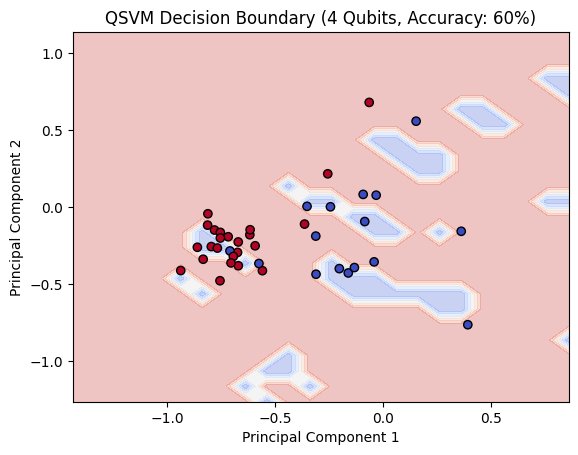

In [10]:
# Create a mesh grid to plot the decision boundary
h = .1  # step size in the mesh
x_min, x_max = X_train_sub[:, 0].min() - 0.5, X_train_sub[:, 0].max() + 0.5
y_min, y_max = X_train_sub[:, 1].min() - 0.5, X_train_sub[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# To predict on the grid, we need 4 features. We'll pad the rest with zeros.
grid_points = np.c_[xx.ravel(), yy.ravel(), np.zeros(xx.ravel().shape), np.zeros(xx.ravel().shape)]
Z = qsvc.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_train_sub[:, 0], X_train_sub[:, 1], c=y_train_sub, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title(f"QSVM Decision Boundary (4 Qubits, Accuracy: {accuracy*100:.0f}%)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()